In [1]:
import pandas as pd
import os
from glob import glob

# ============================================================
# 0. PennDOT Helper — Convert DMS ("40 40:02.398") → Decimal
# ============================================================

def dms_to_decimal(dms_string):
    """
    Convert PennDOT DMS format '40 40:02.398' into decimal degrees.
    """
    try:
        if not isinstance(dms_string, str):
            return None

        parts = dms_string.strip().split(" ")
        deg = float(parts[0])

        min_sec = parts[1].split(":")
        minutes = float(min_sec[0])
        seconds = float(min_sec[1])

        dec = deg + minutes/60 + seconds/3600
        return dec
    except:
        return None

In [2]:
# ============================================================
# AUTO-DETECT ALL YEARS
# ============================================================

BASE_DIR = "."

def load_all_years(file_pattern):
    df_list = []
    file_list = []

    for folder in sorted(os.listdir(BASE_DIR)):
        if folder.startswith("Allegheny_") and os.path.isdir(os.path.join(BASE_DIR, folder)):
            search_pattern = os.path.join(BASE_DIR, folder, file_pattern)
            matches = glob(search_pattern)
            for f in matches:
                print(f"Loading: {f}")
                file_list.append(f)
                df_list.append(pd.read_csv(f, dtype=str))

    if not df_list:
        print(f"WARNING: No files found for pattern: {file_pattern}")
        return pd.DataFrame()

    df = pd.concat(df_list, ignore_index=True)
    print(f" → Loaded {len(df):,} rows from {len(file_list)} files.\n")
    return df


In [3]:
# ============================================================
# LOAD DATASETS
# ============================================================

crash   = load_all_years("*CRASH_ALLEGHENY*.csv")
vehicle = load_all_years("*VEHICLE_ALLEGHENY*.csv")
roadway = load_all_years("*ROADWAY_ALLEGHENY*.csv")

print("=== SUMMARY ===")
print(f"Crash records:   {len(crash):,}")
print(f"Vehicle records: {len(vehicle):,}")
print(f"Roadway records: {len(roadway):,}")

Loading: ./Allegheny_2005/CRASH_ALLEGHENY_2005.csv
Loading: ./Allegheny_2006/CRASH_ALLEGHENY_2006.csv
Loading: ./Allegheny_2007/CRASH_ALLEGHENY_2007.csv
Loading: ./Allegheny_2008/CRASH_ALLEGHENY_2008.csv
Loading: ./Allegheny_2009/CRASH_ALLEGHENY_2009.csv
Loading: ./Allegheny_2010/CRASH_ALLEGHENY_2010.csv
Loading: ./Allegheny_2011/CRASH_ALLEGHENY_2011.csv
Loading: ./Allegheny_2012/CRASH_ALLEGHENY_2012.csv
Loading: ./Allegheny_2013/CRASH_ALLEGHENY_2013.csv
Loading: ./Allegheny_2014/CRASH_ALLEGHENY_2014.csv
Loading: ./Allegheny_2015/CRASH_ALLEGHENY_2015.csv
Loading: ./Allegheny_2016/CRASH_ALLEGHENY_2016.csv
Loading: ./Allegheny_2017/CRASH_ALLEGHENY_2017.csv
Loading: ./Allegheny_2020/CRASH_ALLEGHENY_2020.csv
Loading: ./Allegheny_2021/CRASH_ALLEGHENY_2021.csv
Loading: ./Allegheny_2022/CRASH_ALLEGHENY_2022.csv
Loading: ./Allegheny_2023/CRASH_ALLEGHENY_2023.csv
Loading: ./Allegheny_2024/CRASH_ALLEGHENY_2024.csv
 → Loaded 211,905 rows from 18 files.

Loading: ./Allegheny_2005/VEHICLE_ALLEGHENY

In [4]:
# ============================================================
# Section - stats - general stats on RTOR crash for non-motorists
# ============================================================

In [5]:
print("\n================= NON-MOTORIST HIT RATE COMPARISON =================")

# ---------------------------------------------------------
# Ensure numeric movement codes and NONMOTR_COUNT
# ---------------------------------------------------------
vehicle["VEH_MOVEMENT"] = pd.to_numeric(vehicle["VEH_MOVEMENT"], errors="coerce").fillna(0).astype(int)
crash["NONMOTR_COUNT"] = pd.to_numeric(crash["NONMOTR_COUNT"], errors="coerce").fillna(0).astype(int)

# ---------------------------------------------------------
# MOVEMENT CODES
# ---------------------------------------------------------
RIGHT_TURN = {9, 10}   # 09 = RTOR, 10 = right turn
LEFT_TURN = {11, 12}   # From PennDOT dictionary

# ---------------------------------------------------------
# 1. LEFT-TURN CRASHES
# ---------------------------------------------------------
left_turn_crns = (
    vehicle[vehicle["VEH_MOVEMENT"].isin(LEFT_TURN)]
    .groupby("CRN")
    .size()
    .reset_index(name="LEFT_TURN_COUNT")
)

crash_left = crash.merge(left_turn_crns, on="CRN", how="left")
crash_left["LEFT_FLAG"] = crash_left["LEFT_TURN_COUNT"].fillna(0).astype(int).gt(0).astype(int)

total_left = len(crash_left[crash_left["LEFT_FLAG"] == 1])
left_nonmotor = len(crash_left[(crash_left["LEFT_FLAG"] == 1) & (crash_left["NONMOTR_COUNT"] > 0)])

pct_left = (left_nonmotor / total_left * 100) if total_left > 0 else 0


# ---------------------------------------------------------
# 2. RIGHT-TURN CRASHES (already computed earlier)
# ---------------------------------------------------------
right_turn_crns = (
    vehicle[vehicle["VEH_MOVEMENT"].isin(RIGHT_TURN)]
    .groupby("CRN")
    .size()
    .reset_index(name="RIGHT_TURN_COUNT")
)

crash_right = crash.merge(right_turn_crns, on="CRN", how="left")
crash_right["RIGHT_FLAG"] = crash_right["RIGHT_TURN_COUNT"].fillna(0).astype(int).gt(0).astype(int)

total_right = len(crash_right[crash_right["RIGHT_FLAG"] == 1])
right_nonmotor = len(crash_right[(crash_right["RIGHT_FLAG"] == 1) & (crash_right["NONMOTR_COUNT"] > 0)])

pct_right = (right_nonmotor / total_right * 100) if total_right > 0 else 0


# ---------------------------------------------------------
# 3. RTOR CRASHES (VEH_MOVEMENT = 09 ONLY)
# ---------------------------------------------------------
rtor_crns = (
    vehicle[vehicle["VEH_MOVEMENT"] == 9]
    .groupby("CRN")
    .size()
    .reset_index(name="RTOR_COUNT")
)

crash_rtor = crash.merge(rtor_crns, on="CRN", how="left")
crash_rtor["RTOR_FLAG"] = crash_rtor["RTOR_COUNT"].fillna(0).astype(int).gt(0).astype(int)

total_rtor = len(crash_rtor[crash_rtor["RTOR_FLAG"] == 1])
rtor_nonmotor = len(crash_rtor[(crash_rtor["RTOR_FLAG"] == 1) & (crash_rtor["NONMOTR_COUNT"] > 0)])

pct_rtor = (rtor_nonmotor / total_rtor * 100) if total_rtor > 0 else 0


# ---------------------------------------------------------
# DISPLAY RESULTS
# ---------------------------------------------------------
print(f"\nLEFT TURN CRASHES:")
print(f"  Total left-turn crashes:              {total_left:,}")
print(f"  Non-motorist left-turn crashes:       {left_nonmotor:,}")
print(f"  Non-motorist hit rate (LEFT):         {pct_left:.2f}%")

print(f"\nRIGHT TURN CRASHES:")
print(f"  Total right-turn crashes:             {total_right:,}")
print(f"  Non-motorist right-turn crashes:      {right_nonmotor:,}")
print(f"  Non-motorist hit rate (RIGHT):        {pct_right:.2f}%")

print(f"\nRTOR CRASHES (Right Turn On Red):")
print(f"  Total RTOR crashes:                   {total_rtor:,}")
print(f"  Non-motorist RTOR crashes:            {rtor_nonmotor:,}")
print(f"  Non-motorist hit rate (RTOR):         {pct_rtor:.2f}%")



================= NON-MOTORIST HIT RATE COMPARISON =================

LEFT TURN CRASHES:
  Total left-turn crashes:              35,669
  Non-motorist left-turn crashes:       2,187
  Non-motorist hit rate (LEFT):         6.13%

RIGHT TURN CRASHES:
  Total right-turn crashes:             8,324
  Non-motorist right-turn crashes:      655
  Non-motorist hit rate (RIGHT):        7.87%

RTOR CRASHES (Right Turn On Red):
  Total RTOR crashes:                   413
  Non-motorist RTOR crashes:            77
  Non-motorist hit rate (RTOR):         18.64%


In [6]:
print("\n=== Right-Turn Crash Analysis: Non-Motorist Involvement (ALL crashes) ===")

# ----------------------------------------
# 1. Ensure NONMOTR_COUNT is numeric
# ----------------------------------------
crash["NONMOTR_COUNT"] = (
    pd.to_numeric(crash["NONMOTR_COUNT"], errors="coerce")
    .fillna(0)
    .astype(int)
)

# ----------------------------------------
# 2. Clean VEH_MOVEMENT on vehicle table
# ----------------------------------------
vehicle["VEH_MOVEMENT"] = (
    pd.to_numeric(vehicle["VEH_MOVEMENT"], errors="coerce")
    .fillna(0)
    .astype(int)
)

# Right turn = codes 9 + 10
RIGHT_TURN_CODES = {9, 10}

# All CRNs with right-turn movements
right_turn_crns_all = (
    vehicle[vehicle["VEH_MOVEMENT"].isin(RIGHT_TURN_CODES)]
    .groupby("CRN")
    .size()
    .reset_index(name="RIGHT_TURN_COUNT")
)

# ----------------------------------------
# 3. Merge right-turn info back to full crash table
# ----------------------------------------
crash_with_rt = crash.merge(
    right_turn_crns_all[["CRN", "RIGHT_TURN_COUNT"]],
    on="CRN",
    how="left"
)

crash_with_rt["RIGHT_TURN_FLAG"] = (
    crash_with_rt["RIGHT_TURN_COUNT"]
    .fillna(0).astype(int).gt(0).astype(int)
)

# ----------------------------------------
# 4. All right-turn crashes
# ----------------------------------------
rt_all = crash_with_rt[crash_with_rt["RIGHT_TURN_FLAG"] == 1].copy()
total_rt = len(rt_all)

# ----------------------------------------
# 5. Right-turn crashes with non-motorists
# ----------------------------------------
rt_nm = rt_all[rt_all["NONMOTR_COUNT"] > 0].copy()
nm_rt = len(rt_nm)

pct_nm_rt = (nm_rt / total_rt * 100) if total_rt > 0 else 0

print(f"Total right-turn crashes (all types): {total_rt}")
print(f"Right-turn crashes involving pedestrians/cyclists: {nm_rt}")
print(f"Percentage involving non-motorists: {pct_nm_rt:.2f}%")

# ----------------------------------------
# 6. Breakdown: pedestrians vs bicycles
# ----------------------------------------
rt_nm["PED_COUNT"] = pd.to_numeric(rt_nm["PED_COUNT"], errors="coerce").fillna(0).astype(int)
rt_nm["BICYCLE_COUNT"] = pd.to_numeric(rt_nm["BICYCLE_COUNT"], errors="coerce").fillna(0).astype(int)

ped_rt = rt_nm[rt_nm["PED_COUNT"] > 0]
bike_rt = rt_nm[rt_nm["BICYCLE_COUNT"] > 0]

print("\nBreakdown among these pedestrian/cyclist right-turn crashes:")
print(f"  Pedestrian right-turn crashes: {len(ped_rt)}")
print(f"  Bicycle right-turn crashes:    {len(bike_rt)}")

if nm_rt > 0:
    print(f"  Pedestrian share: {len(ped_rt) / nm_rt * 100:.1f}%")
    print(f"  Bicycle share:    {len(bike_rt) / nm_rt * 100:.1f}%")



=== Right-Turn Crash Analysis: Non-Motorist Involvement (ALL crashes) ===
Total right-turn crashes (all types): 8324
Right-turn crashes involving pedestrians/cyclists: 655
Percentage involving non-motorists: 7.87%

Breakdown among these pedestrian/cyclist right-turn crashes:
  Pedestrian right-turn crashes: 492
  Bicycle right-turn crashes:    163
  Pedestrian share: 75.1%
  Bicycle share:    24.9%


In [7]:
print("\n=== Serious Injury Analysis (Pedestrians & Cyclists in Right-Turn Crashes) ===")

# -------------------------------
# Helper to clean numeric columns
# -------------------------------
def clean_int(col):
    return pd.to_numeric(rt_nm.get(col, 0), errors="coerce").fillna(0).astype(int)

# Injury fields
rt_nm["PED_SUSP_SERIOUS_INJ_COUNT"]     = clean_int("PED_SUSP_SERIOUS_INJ_COUNT")
rt_nm["PED_DEATH_COUNT"]                = clean_int("PED_DEATH_COUNT")
rt_nm["BICYCLE_SUSP_SERIOUS_INJ_COUNT"] = clean_int("BICYCLE_SUSP_SERIOUS_INJ_COUNT")
rt_nm["BICYCLE_DEATH_COUNT"]            = clean_int("BICYCLE_DEATH_COUNT")

# Mode involvement fields
rt_nm["PED_COUNT"]     = clean_int("PED_COUNT")
rt_nm["BICYCLE_COUNT"] = clean_int("BICYCLE_COUNT")

# ============================================================
# 1. PEDESTRIAN SERIOUS INJURY ANALYSIS
# ============================================================

ped_rt = rt_nm[rt_nm["PED_COUNT"] > 0].copy()
total_ped_rt = len(ped_rt)

serious_ped_rt = ped_rt[ped_rt["PED_SUSP_SERIOUS_INJ_COUNT"] > 0]
num_serious_ped = len(serious_ped_rt)

fatal_ped_rt = ped_rt[ped_rt["PED_DEATH_COUNT"] > 0]
num_fatal_ped = len(fatal_ped_rt)

pct_serious_ped = (num_serious_ped / total_ped_rt * 100) if total_ped_rt > 0 else 0
pct_fatal_ped   = (num_fatal_ped   / total_ped_rt * 100) if total_ped_rt > 0 else 0

print("\n--- Pedestrian Right-Turn Crash Outcomes ---")
print(f"Total pedestrian-involved RT crashes: {total_ped_rt}")
print(f"Pedestrians seriously injured:        {num_serious_ped}")
print(f"Pedestrians killed:                   {num_fatal_ped}")
print(f"Serious injury rate:                  {pct_serious_ped:.2f}%")
print(f"Fatality rate:                        {pct_fatal_ped:.2f}%")


# ============================================================
# 2. CYCLIST SERIOUS INJURY ANALYSIS
# ============================================================

bike_rt = rt_nm[rt_nm["BICYCLE_COUNT"] > 0].copy()
total_bike_rt = len(bike_rt)

serious_bike_rt = bike_rt[bike_rt["BICYCLE_SUSP_SERIOUS_INJ_COUNT"] > 0]
num_serious_bike = len(serious_bike_rt)

fatal_bike_rt = bike_rt[bike_rt["BICYCLE_DEATH_COUNT"] > 0]
num_fatal_bike = len(fatal_bike_rt)

pct_serious_bike = (num_serious_bike / total_bike_rt * 100) if total_bike_rt > 0 else 0
pct_fatal_bike   = (num_fatal_bike   / total_bike_rt * 100) if total_bike_rt > 0 else 0

print("\n--- Cyclist Right-Turn Crash Outcomes ---")
print(f"Total cyclist-involved RT crashes:    {total_bike_rt}")
print(f"Cyclists seriously injured:           {num_serious_bike}")
print(f"Cyclists killed:                      {num_fatal_bike}")
print(f"Serious injury rate:                  {pct_serious_bike:.2f}%")
print(f"Fatality rate:                        {pct_fatal_bike:.2f}%")



=== Serious Injury Analysis (Pedestrians & Cyclists in Right-Turn Crashes) ===

--- Pedestrian Right-Turn Crash Outcomes ---
Total pedestrian-involved RT crashes: 492
Pedestrians seriously injured:        17
Pedestrians killed:                   7
Serious injury rate:                  3.46%
Fatality rate:                        1.42%

--- Cyclist Right-Turn Crash Outcomes ---
Total cyclist-involved RT crashes:    163
Cyclists seriously injured:           5
Cyclists killed:                      0
Serious injury rate:                  3.07%
Fatality rate:                        0.00%


In [8]:
print("\n=== SERIOUS INJURY ANALYSIS FOR MOTORISTS IN RIGHT-TURN CRASHES ===")

# ----------------------------------------------------
# 1. Motorist-only right-turn crashes
#    (RIGHT_TURN_FLAG = 1 AND NONMOTR_COUNT = 0)
# ----------------------------------------------------
rt_motor = rt_all[rt_all["NONMOTR_COUNT"] == 0].copy()
total_motor_rt = len(rt_motor)

print(f"Total motorist-only right-turn crashes: {total_motor_rt}")

# ----------------------------------------------------
# 2. Clean injury columns
# ----------------------------------------------------
rt_motor["SUSP_SERIOUS_INJ_COUNT"] = pd.to_numeric(
    rt_motor.get("SUSP_SERIOUS_INJ_COUNT", 0),
    errors="coerce"
).fillna(0).astype(int)

rt_motor["DEATH_COUNT"] = pd.to_numeric(
    rt_motor.get("FATAL_COUNT", 0),
    errors="coerce"
).fillna(0).astype(int)

# ----------------------------------------------------
# 3. Count serious injuries & deaths
# ----------------------------------------------------
motor_serious = rt_motor[rt_motor["SUSP_SERIOUS_INJ_COUNT"] > 0]
num_motor_serious = len(motor_serious)

motor_fatal = rt_motor[rt_motor["DEATH_COUNT"] > 0]
num_motor_fatal = len(motor_fatal)

pct_motor_serious = (num_motor_serious / total_motor_rt * 100) if total_motor_rt > 0 else 0
pct_motor_fatal   = (num_motor_fatal   / total_motor_rt * 100) if total_motor_rt > 0 else 0

print(f"Motorist serious injuries in RT crashes: {num_motor_serious}")
print(f"Motorist deaths in RT crashes:           {num_motor_fatal}")
print(f"Motorist serious injury rate:            {pct_motor_serious:.2f}%")
print(f"Motorist fatality rate:                  {pct_motor_fatal:.2f}%")



=== SERIOUS INJURY ANALYSIS FOR MOTORISTS IN RIGHT-TURN CRASHES ===
Total motorist-only right-turn crashes: 7669
Motorist serious injuries in RT crashes: 87
Motorist deaths in RT crashes:           15
Motorist serious injury rate:            1.13%
Motorist fatality rate:                  0.20%


In [9]:
# ============================================================
# RT vs RTOR
# ============================================================

print("\n=== COUNT of VEH_MOVEMENT Codes 09 and 10 (ALL YEARS, COUNTY-WIDE) ===")

# Count right-turn on red (09)
count_09 = (vehicle["VEH_MOVEMENT"] == 9).sum()

# Count right-turn (general right turn, not necessarily on red) (10)
count_10 = (vehicle["VEH_MOVEMENT"] == 10).sum()

# Combined (any right turn)
count_any_rt = count_09 + count_10

print(f"Code 09 (Right Turn on Red):   {count_09:,}")
print(f"Code 10 (Right Turn):          {count_10:,}")
print(f"Total right-turn units (09+10): {count_any_rt:,}")



=== COUNT of VEH_MOVEMENT Codes 09 and 10 (ALL YEARS, COUNTY-WIDE) ===
Code 09 (Right Turn on Red):   423
Code 10 (Right Turn):          8,290
Total right-turn units (09+10): 8,713


In [10]:
print("\n=== Identifying Non-Motorist RTOR Crashes (Code 09 Only) ===")

# -----------------------------------------------------------
# 1. Ensure numeric fields are clean
# -----------------------------------------------------------

crash["NONMOTR_COUNT"] = (
    pd.to_numeric(crash["NONMOTR_COUNT"], errors="coerce")
    .fillna(0).astype(int)
)

vehicle["VEH_MOVEMENT"] = (
    pd.to_numeric(vehicle["VEH_MOVEMENT"], errors="coerce")
    .fillna(0).astype(int)
)

# -----------------------------------------------------------
# 2. Identify crashes with a Right-Turn-On-Red (RTOR) movement
# -----------------------------------------------------------

RTOR_CODE = 9     # From PennDOT dictionary

# CRNs with at least one RTOR unit
rtor_units = vehicle[vehicle["VEH_MOVEMENT"] == RTOR_CODE]

crn_rtor = (
    rtor_units.groupby("CRN")
    .size()
    .reset_index(name="RTOR_UNIT_COUNT")
)

print(f"Total RTOR units (code 09): {len(rtor_units):,}")
print(f"Total RTOR crashes (unique CRN): {len(crn_rtor):,}")

# -----------------------------------------------------------
# 3. Merge RTOR info into the crash table
# -----------------------------------------------------------

crash_rtor = crash.merge(crn_rtor, on="CRN", how="left")
crash_rtor["RTOR_FLAG"] = crash_rtor["RTOR_UNIT_COUNT"].fillna(0).astype(int).gt(0).astype(int)

# -----------------------------------------------------------
# 4. Filter: crashes that are BOTH RTOR AND involve non-motorists
# -----------------------------------------------------------

rtor_nonmotr = crash_rtor[
    (crash_rtor["RTOR_FLAG"] == 1) &
    (crash_rtor["NONMOTR_COUNT"] > 0)
].copy()

print(f"\nRTOR crashes involving pedestrians or cyclists: {len(rtor_nonmotr):,}")

# -----------------------------------------------------------
# 5. Breakdown by pedestrian vs bicycle
# -----------------------------------------------------------

rtor_nonmotr["PED_COUNT"] = pd.to_numeric(rtor_nonmotr["PED_COUNT"], errors="coerce").fillna(0).astype(int)
rtor_nonmotr["BICYCLE_COUNT"] = pd.to_numeric(rtor_nonmotr["BICYCLE_COUNT"], errors="coerce").fillna(0).astype(int)

ped_rtor = rtor_nonmotr[rtor_nonmotr["PED_COUNT"] > 0]
bike_rtor = rtor_nonmotr[rtor_nonmotr["BICYCLE_COUNT"] > 0]

print("\nBreakdown among RTOR non-motorist crashes:")
print(f"  Pedestrian RTOR crashes: {len(ped_rtor):,}")
print(f"  Bicycle RTOR crashes:    {len(bike_rtor):,}")

total_rtor_nm = len(rtor_nonmotr)
if total_rtor_nm > 0:
    print(f"  Pedestrian share: {len(ped_rtor) / total_rtor_nm * 100:.1f}%")
    print(f"  Bicycle share:    {len(bike_rtor) / total_rtor_nm * 100:.1f}%")



=== Identifying Non-Motorist RTOR Crashes (Code 09 Only) ===
Total RTOR units (code 09): 423
Total RTOR crashes (unique CRN): 413

RTOR crashes involving pedestrians or cyclists: 77

Breakdown among RTOR non-motorist crashes:
  Pedestrian RTOR crashes: 57
  Bicycle RTOR crashes:    20
  Pedestrian share: 74.0%
  Bicycle share:    26.0%


In [11]:
print("\n=== Serious Injury & Fatality Analysis for RTOR Non-Motorist Crashes ===")

# -----------------------------------------------------------
# 1. Clean injury fields
# -----------------------------------------------------------

def clean_int(df, col):
    return pd.to_numeric(df.get(col, 0), errors="coerce").fillna(0).astype(int)

rtor_nonmotr["PED_SUSP_SERIOUS_INJ_COUNT"]     = clean_int(rtor_nonmotr, "PED_SUSP_SERIOUS_INJ_COUNT")
rtor_nonmotr["PED_DEATH_COUNT"]                = clean_int(rtor_nonmotr, "PED_DEATH_COUNT")
rtor_nonmotr["BICYCLE_SUSP_SERIOUS_INJ_COUNT"] = clean_int(rtor_nonmotr, "BICYCLE_SUSP_SERIOUS_INJ_COUNT")
rtor_nonmotr["BICYCLE_DEATH_COUNT"]            = clean_int(rtor_nonmotr, "BICYCLE_DEATH_COUNT")

rtor_nonmotr["PED_COUNT"]     = clean_int(rtor_nonmotr, "PED_COUNT")
rtor_nonmotr["BICYCLE_COUNT"] = clean_int(rtor_nonmotr, "BICYCLE_COUNT")

# -----------------------------------------------------------
# 2. PEDESTRIAN RTOR Injury/Fatality Analysis
# -----------------------------------------------------------

ped_rtor = rtor_nonmotr[rtor_nonmotr["PED_COUNT"] > 0].copy()
total_ped_rtor = len(ped_rtor)

ped_serious = ped_rtor[ped_rtor["PED_SUSP_SERIOUS_INJ_COUNT"] > 0]
num_ped_serious = len(ped_serious)

ped_fatal = ped_rtor[ped_rtor["PED_DEATH_COUNT"] > 0]
num_ped_fatal = len(ped_fatal)

pct_ped_serious = (num_ped_serious / total_ped_rtor * 100) if total_ped_rtor > 0 else 0
pct_ped_fatal   = (num_ped_fatal   / total_ped_rtor * 100) if total_ped_rtor > 0 else 0

print("\n--- Pedestrians (RTOR Crashes) ---")
print(f"Total pedestrian RTOR crashes:       {total_ped_rtor}")
print(f"Pedestrians seriously injured:       {num_ped_serious}")
print(f"Pedestrians killed:                  {num_ped_fatal}")
print(f"Serious injury rate:                 {pct_ped_serious:.2f}%")
print(f"Fatality rate:                       {pct_ped_fatal:.2f}%")


# -----------------------------------------------------------
# 3. CYCLIST RTOR Injury/Fatality Analysis
# -----------------------------------------------------------

bike_rtor = rtor_nonmotr[rtor_nonmotr["BICYCLE_COUNT"] > 0].copy()
total_bike_rtor = len(bike_rtor)

bike_serious = bike_rtor[bike_rtor["BICYCLE_SUSP_SERIOUS_INJ_COUNT"] > 0]
num_bike_serious = len(bike_serious)

bike_fatal = bike_rtor[bike_rtor["BICYCLE_DEATH_COUNT"] > 0]
num_bike_fatal = len(bike_fatal)

pct_bike_serious = (num_bike_serious / total_bike_rtor * 100) if total_bike_rtor > 0 else 0
pct_bike_fatal   = (num_bike_fatal   / total_bike_rtor * 100) if total_bike_rtor > 0 else 0

print("\n--- Cyclists (RTOR Crashes) ---")
print(f"Total cyclist RTOR crashes:          {total_bike_rtor}")
print(f"Cyclists seriously injured:          {num_bike_serious}")
print(f"Cyclists killed:                     {num_bike_fatal}")
print(f"Serious injury rate:                 {pct_bike_serious:.2f}%")
print(f"Fatality rate:                       {pct_bike_fatal:.2f}%")



=== Serious Injury & Fatality Analysis for RTOR Non-Motorist Crashes ===

--- Pedestrians (RTOR Crashes) ---
Total pedestrian RTOR crashes:       57
Pedestrians seriously injured:       0
Pedestrians killed:                  1
Serious injury rate:                 0.00%
Fatality rate:                       1.75%

--- Cyclists (RTOR Crashes) ---
Total cyclist RTOR crashes:          20
Cyclists seriously injured:          2
Cyclists killed:                     0
Serious injury rate:                 10.00%
Fatality rate:                       0.00%


In [12]:
# ============================================================
# 1. Convert LAT/LON to decimal degrees
# ============================================================

print("\n=== Converting DMS → Decimal Degrees ===")

crash["LAT_DEC"] = crash["LATITUDE"].apply(dms_to_decimal)
crash["LON_DEC"] = crash["LONGITUDE"].apply(dms_to_decimal)

print("Sample lat/lon conversion:")
print(crash[["LATITUDE", "LAT_DEC", "LONGITUDE", "LON_DEC"]].head())




=== Converting DMS → Decimal Degrees ===
Sample lat/lon conversion:
       LATITUDE    LAT_DEC     LONGITUDE    LON_DEC
0           NaN        NaN           NaN        NaN
1  40 31:15.600  40.521000  80 13:27.840  80.224400
2  40 26:43.605  40.445446  79 45:54.957  79.765266
3  40 17:38.295  40.293971  79 55:01.830  79.917175
4           NaN        NaN           NaN        NaN


In [13]:
# ============================================================
# 2. Clean NONMOTR_COUNT
# ============================================================

print("\n=== Cleaning NONMOTR_COUNT ===")

crash["NONMOTR_COUNT"] = (
    pd.to_numeric(crash["NONMOTR_COUNT"], errors="coerce")
    .fillna(0)
    .astype(int)
)

print(f"Unique NONMOTR_COUNT values after cleaning: {crash['NONMOTR_COUNT'].unique()}")



=== Cleaning NONMOTR_COUNT ===
Unique NONMOTR_COUNT values after cleaning: [ 1  0  2  3  4 81  9  8]


In [14]:

# ============================================================
# 3. Filter to crashes with pedestrians OR cyclists
# ============================================================

print("\n=== Filtering crashes with non-motorists ===")

crash_nonmotr = crash[ crash["NONMOTR_COUNT"] > 0 ].copy()

print(f"Crashes with pedestrians or cyclists: {len(crash_nonmotr):,}")



=== Filtering crashes with non-motorists ===
Crashes with pedestrians or cyclists: 8,420


In [15]:

# ============================================================
# 4. Detect intersection crashes using INTERSECT_TYPE
# According to PennDOT dictionary:
#   00 = NOT intersection
#   01–13 = intersection
#   99 = unknown (exclude)
# ============================================================

print("\n=== Filtering intersection crashes ===")

crash_nonmotr["INTERSECT_TYPE"] = pd.to_numeric(
    crash_nonmotr["INTERSECT_TYPE"], errors="coerce"
).fillna(0).astype(int)

crash_intersections = crash_nonmotr[
    (crash_nonmotr["INTERSECT_TYPE"] >= 1) &
    (crash_nonmotr["INTERSECT_TYPE"] <= 13)
].copy()

print(f"Intersection (non-motorist) crashes: {len(crash_intersections):,}")


=== Filtering intersection crashes ===
Intersection (non-motorist) crashes: 5,254


In [16]:
# ============================================================
# 5. Right-turn detection from VEH_MOVEMENT
# Right turn codes:
#   09 = Right turn on red
#   10 = Right turn
# ============================================================

print("\n=== Detecting right-turn involved crashes ===")

vehicle["VEH_MOVEMENT"] = pd.to_numeric(
    vehicle["VEH_MOVEMENT"], errors="coerce"
).fillna(0).astype(int)

RIGHT_TURN_CODES = {9, 10}

right_turn_crns = (
    vehicle[vehicle["VEH_MOVEMENT"].isin(RIGHT_TURN_CODES)]
    .groupby("CRN")
    .size()
    .reset_index(name="RIGHT_TURN_COUNT")
)

print(f"Crashes with right-turn vehicles: {len(right_turn_crns):,}")

# Merge
crash_intersections = crash_intersections.merge(
    right_turn_crns, on="CRN", how="left"
)

crash_intersections["RIGHT_TURN_FLAG"] = crash_intersections["RIGHT_TURN_COUNT"].fillna(0).astype(int).apply(
    lambda x: 1 if x > 0 else 0
)

print("Right-turn flags applied.")



=== Detecting right-turn involved crashes ===
Crashes with right-turn vehicles: 8,324
Right-turn flags applied.


In [17]:
# ============================================================
# 6. Add roadway names from ROADWAY.csv
# ============================================================

print("\n=== Adding roadway names ===")

roadway["STREET_NAME"] = roadway["STREET_NAME"].fillna("").astype(str)

roadway_clean = roadway[ roadway["STREET_NAME"].str.strip() != "" ].copy()

roadway_grouped = (
    roadway_clean.groupby("CRN")["STREET_NAME"]
    .apply(lambda x: "; ".join(sorted(set(x))))
    .reset_index()
)

crash_intersections = crash_intersections.merge(
    roadway_grouped,
    on="CRN",
    how="left"
)

print("Roadway names merged.")
print(f"Example STREET_NAME values:\n{crash_intersections['STREET_NAME'].head()}")




=== Adding roadway names ===
Roadway names merged.
Example STREET_NAME values:
0                     FIFTH AV; GRAEME ST
1              BOUNDARY ST; OHIO RIVER BL
2              BOUNDARY ST; OHIO RIVER BL
3                   LINCOLN AV; S STAR AV
4    LIBERTY AVENUE AV; STANWIX STREET ST
Name: STREET_NAME, dtype: object


In [20]:
# ============================================================
# COUNTY-WIDE INTERSECTION MAP (RIGHT-TURN + NON-MOTORIST)
# With hover popups showing crash counts per intersection
# ============================================================

import folium
import numpy as np

print("\n=== Building Hoverable Intersection Map (County-Wide) ===")

# ------------------------------------------------------------
# 1. Start from your intersection-filtered dataset
#    crash_intersections already has:
#    - NONMOTR_COUNT > 0
#    - intersection-only
#    - RIGHT_TURN_FLAG
#    - merged STREET_NAME
# ------------------------------------------------------------
df = crash_intersections.copy()

# Keep only non-motorist + right-turn
df = df[(df["NONMOTR_COUNT"] > 0) & (df["RIGHT_TURN_FLAG"] == 1)].copy()
print(f"Right-turn non-motorist intersection crashes: {len(df)}")

# Clean coordinates
df["LAT_DEC"] = pd.to_numeric(df["LAT_DEC"], errors="coerce")
df["LON_DEC"] = pd.to_numeric(df["LON_DEC"], errors="coerce")
df = df[df["LAT_DEC"].notna() & df["LON_DEC"].notna()]

# Fix longitude sign
df.loc[df["LON_DEC"] > 0, "LON_DEC"] *= -1

# ------------------------------------------------------------
# 2. Severity weighting
# ------------------------------------------------------------
df["PED_SUSP_SERIOUS_INJ_COUNT"]     = pd.to_numeric(df.get("PED_SUSP_SERIOUS_INJ_COUNT", 0), errors="coerce").fillna(0)
df["PED_DEATH_COUNT"]                = pd.to_numeric(df.get("PED_DEATH_COUNT", 0), errors="coerce").fillna(0)
df["BICYCLE_SUSP_SERIOUS_INJ_COUNT"] = pd.to_numeric(df.get("BICYCLE_SUSP_SERIOUS_INJ_COUNT", 0), errors="coerce").fillna(0)
df["BICYCLE_DEATH_COUNT"]            = pd.to_numeric(df.get("BICYCLE_DEATH_COUNT", 0), errors="coerce").fillna(0)

df["SEVERITY_SCORE"] = (
    1
    + 4 * (df["PED_SUSP_SERIOUS_INJ_COUNT"] + df["BICYCLE_SUSP_SERIOUS_INJ_COUNT"])
    + 10 * (df["PED_DEATH_COUNT"] + df["BICYCLE_DEATH_COUNT"])
)

# ------------------------------------------------------------
# 3. Create INTERSECTION_ID as the grouped field
# ------------------------------------------------------------
df["INTERSECTION_ID"] = df["STREET_NAME"].fillna("").astype(str)

# ------------------------------------------------------------
# 4. Group by intersection
# ------------------------------------------------------------
grouped = (
    df.groupby("INTERSECTION_ID")
      .agg(
          total_crashes=("CRN", "count"),
          right_turn_crashes=("RIGHT_TURN_FLAG", "sum"),
          severity=("SEVERITY_SCORE", "sum"),
          lat=("LAT_DEC", "mean"),
          lon=("LON_DEC", "mean"),
          ped_injuries=("PED_SUSP_SERIOUS_INJ_COUNT", "sum"),
          ped_deaths=("PED_DEATH_COUNT", "sum"),
          bike_injuries=("BICYCLE_SUSP_SERIOUS_INJ_COUNT", "sum"),
          bike_deaths=("BICYCLE_DEATH_COUNT", "sum")
      )
      .reset_index()
)

print(f"Total intersections with right-turn non-motorist crashes: {len(grouped)}")

# Filter out intersections with no coordinate
grouped = grouped[grouped["lat"].notna() & grouped["lon"].notna()]

# ------------------------------------------------------------
# 5. Scaling for marker size & color
# ------------------------------------------------------------
max_crashes = grouped["total_crashes"].max()
max_sev = grouped["severity"].max()

# Marker size (scaled)
grouped["marker_size"] = grouped["total_crashes"].apply(
    lambda x: 6 + 40 * (x / max_crashes)
)

# Color scale (green → red)
def severity_color(sev):
    r = int(min(255, (sev / max_sev) * 255))
    g = int(max(0, 200 - (sev / max_sev) * 200))
    return f"#{r:02x}{g:02x}00"

grouped["color"] = grouped["severity"].apply(severity_color)

# ------------------------------------------------------------
# 6. Build Folium Map
# ------------------------------------------------------------
center_lat = df["LAT_DEC"].mean()
center_lon = df["LON_DEC"].mean()

m = folium.Map(
    location=[center_lat, center_lon],
    zoom_start=12,
    tiles="cartodbpositron"
)

# ------------------------------------------------------------
# 7. Add markers with hover popups
# ------------------------------------------------------------
for _, row in grouped.iterrows():
    
    popup_html = f"""
    <b>Intersection:</b> {row['INTERSECTION_ID']}<br>
    <b>Total crashes:</b> {row['total_crashes']}<br>
    <b>Right-turn crashes:</b> {row['right_turn_crashes']}<br>
    <b>Severity score:</b> {row['severity']}<br><br>
    <b>Pedestrian serious injuries:</b> {row['ped_injuries']}<br>
    <b>Pedestrian deaths:</b> {row['ped_deaths']}<br>
    <b>Cyclist serious injuries:</b> {row['bike_injuries']}<br>
    <b>Cyclist deaths:</b> {row['bike_deaths']}<br>
    """

    folium.CircleMarker(
        location=[row["lat"], row["lon"]],
        radius=row["marker_size"],
        color=row["color"],
        fill=True,
        fill_color=row["color"],
        fill_opacity=0.8,
        popup=folium.Popup(popup_html, max_width=350)
    ).add_to(m)

print("✔ Interactive intersection crash map created.")
m



=== Building Hoverable Intersection Map (County-Wide) ===
Right-turn non-motorist intersection crashes: 559
Total intersections with right-turn non-motorist crashes: 479
✔ Interactive intersection crash map created.


In [21]:
m.save("right_turn_heatmap_animation.html")

In [22]:
# ============================================================
# COUNTY-WIDE INTERSECTION MAP (RTOR + NON-MOTORIST)
# ------------------------------------------------------------
# Same style as "RIGHT-TURN + NON-MOTORIST" map
# but filtered to RTOR (code 09) only
# ============================================================

import folium
import numpy as np

print("\n=== Building County-Wide RTOR + Non-Motorist Intersection Map ===")

# ------------------------------------------------------------
# 1. Start with your intersection-filtered dataset
#    crash_intersections contains:
#    - NONMOTR_COUNT
#    - INTERSECT_TYPE filtering
#    - LAT_DEC / LON_DEC
#    - STREET_NAME merged
#    - RIGHT_TURN_FLAG (but we ignore this — we use RTOR only)
# ------------------------------------------------------------

df = crash_intersections.copy()

# ------------------------------------------------------------
# 2. Identify RTOR crashes (VEH_MOVEMENT = 9)
# ------------------------------------------------------------
vehicle["VEH_MOVEMENT"] = pd.to_numeric(vehicle["VEH_MOVEMENT"], errors="coerce").fillna(0).astype(int)
rtor_crns = set(vehicle[vehicle["VEH_MOVEMENT"] == 9]["CRN"].astype(str))

df = df[df["CRN"].astype(str).isin(rtor_crns)].copy()
print(f"RTOR intersection crashes (all): {len(df)}")

# Keep only RTOR + non-motorist
df = df[df["NONMOTR_COUNT"] > 0].copy()
print(f"RTOR + non-motorist crashes: {len(df)}")

# Clean coordinates
df["LAT_DEC"] = pd.to_numeric(df["LAT_DEC"], errors="coerce")
df["LON_DEC"] = pd.to_numeric(df["LON_DEC"], errors="coerce")
df = df[df["LAT_DEC"].notna() & df["LON_DEC"].notna()]

# Fix longitude sign
df.loc[df["LON_DEC"] > 0, "LON_DEC"] *= -1

# ------------------------------------------------------------
# 3. Severity scoring (like before)
# ------------------------------------------------------------

df["PED_SUSP_SERIOUS_INJ_COUNT"]     = pd.to_numeric(df.get("PED_SUSP_SERIOUS_INJ_COUNT", 0), errors="coerce").fillna(0)
df["PED_DEATH_COUNT"]                = pd.to_numeric(df.get("PED_DEATH_COUNT", 0), errors="coerce").fillna(0)
df["BICYCLE_SUSP_SERIOUS_INJ_COUNT"] = pd.to_numeric(df.get("BICYCLE_SUSP_SERIOUS_INJ_COUNT", 0), errors="coerce").fillna(0)
df["BICYCLE_DEATH_COUNT"]            = pd.to_numeric(df.get("BICYCLE_DEATH_COUNT", 0), errors="coerce").fillna(0)

df["SEVERITY_SCORE"] = (
    1
    + 4  * (df["PED_SUSP_SERIOUS_INJ_COUNT"] + df["BICYCLE_SUSP_SERIOUS_INJ_COUNT"])
    + 10 * (df["PED_DEATH_COUNT"] + df["BICYCLE_DEATH_COUNT"])
)

# ------------------------------------------------------------
# 4. Group by INTERSECTION_ID (STREET_NAME)
# ------------------------------------------------------------

df["INTERSECTION_ID"] = df["STREET_NAME"].fillna("").astype(str)

grouped = (
    df.groupby("INTERSECTION_ID")
      .agg(
          total_crashes=("CRN", "count"),
          rtor_crashes=("CRN", "count"),    # identical — all are RTOR already
          severity=("SEVERITY_SCORE", "sum"),
          lat=("LAT_DEC", "mean"),
          lon=("LON_DEC", "mean"),
          ped_injuries=("PED_SUSP_SERIOUS_INJ_COUNT", "sum"),
          ped_deaths=("PED_DEATH_COUNT", "sum"),
          bike_injuries=("BICYCLE_SUSP_SERIOUS_INJ_COUNT", "sum"),
          bike_deaths=("BICYCLE_DEATH_COUNT", "sum")
      )
      .reset_index()
)

print(f"Intersections with RTOR non-motorist crashes: {len(grouped)}")

# Keep only intersections with coordinates
grouped = grouped[grouped["lat"].notna() & grouped["lon"].notna()]

# ------------------------------------------------------------
# 5. Marker sizing + severity color
# ------------------------------------------------------------

max_crashes = grouped["total_crashes"].max()
max_sev = grouped["severity"].max()

grouped["marker_size"] = grouped["total_crashes"].apply(
    lambda x: 6 + 40 * (x / max_crashes)
)

def severity_color(sev):
    r = int(min(255, (sev / max_sev) * 255))
    g = int(max(0, 200 - (sev / max_sev) * 200))
    return f"#{r:02x}{g:02x}00"

grouped["color"] = grouped["severity"].apply(severity_color)

# ------------------------------------------------------------
# 6. Build the folium map
# ------------------------------------------------------------

center_lat = df["LAT_DEC"].mean()
center_lon = df["LON_DEC"].mean()

m_rtor = folium.Map(
    location=[center_lat, center_lon],
    zoom_start=12,
    tiles="cartodbpositron"
)

# ------------------------------------------------------------
# 7. Add markers
# ------------------------------------------------------------

for _, row in grouped.iterrows():
    
    popup_html = f"""
    <b>Intersection:</b> {row['INTERSECTION_ID']}<br>
    <b>Total RTOR crashes:</b> {row['total_crashes']}<br>
    <b>Severity score:</b> {row['severity']}<br><br>

    <b>Pedestrian serious injuries:</b> {row['ped_injuries']}<br>
    <b>Pedestrian deaths:</b> {row['ped_deaths']}<br>

    <b>Cyclist serious injuries:</b> {row['bike_injuries']}<br>
    <b>Cyclist deaths:</b> {row['bike_deaths']}<br>
    """

    folium.CircleMarker(
        location=[row["lat"], row["lon"]],
        radius=row["marker_size"],
        color=row["color"],
        fill=True,
        fill_color=row["color"],
        fill_opacity=0.85,
        popup=folium.Popup(popup_html, max_width=350)
    ).add_to(m_rtor)

print("✔ RTOR + Non-Motorist Intersection Map Created.")
m_rtor



=== Building County-Wide RTOR + Non-Motorist Intersection Map ===
RTOR intersection crashes (all): 77
RTOR + non-motorist crashes: 77
Intersections with RTOR non-motorist crashes: 72
✔ RTOR + Non-Motorist Intersection Map Created.


In [23]:
m_rtor.save("rtor_non_motorist_intersection_map.html")

In [ ]:
#---------------------PREV WORK--------------------------#

In [23]:
# ============================================================
# 7. Restrict to Strip District bounding box
# Use DECIMAL coordinates
# ============================================================

print("\n=== Filtering for Strip District crashes ===")

LAT_MIN, LAT_MAX = 40.445, 40.465
LON_MIN, LON_MAX = -79.996, -79.967   # West is negative!

# Ensure longitude is negative exactly once
crash_intersections["LON_DEC"] = crash_intersections["LON_DEC"].astype(float)
crash_intersections.loc[crash_intersections["LON_DEC"] > 0, "LON_DEC"] *= -1

crash_strip = crash_intersections[
    crash_intersections["LAT_DEC"].between(LAT_MIN, LAT_MAX)
    & crash_intersections["LON_DEC"].between(LON_MIN, LON_MAX)
].copy()

print(f"Final Strip District crashes: {len(crash_strip)}")





=== Filtering for Strip District crashes ===
Final Strip District crashes: 84



=== Generating Map Preview for Strip District ===
✔ Longitude already negative; no correction applied.
✔ GeoDataFrame created with 84 points.


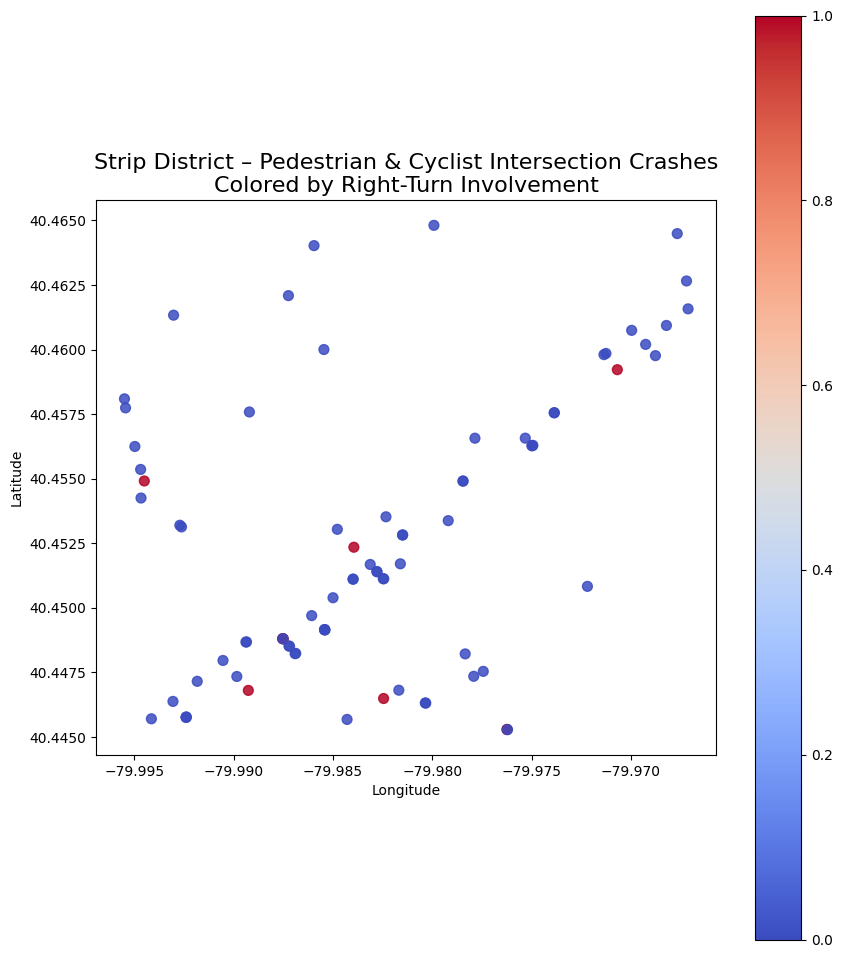

✔ Map preview displayed.


In [24]:
import geopandas as gpd
import matplotlib.pyplot as plt

print("\n=== Generating Map Preview for Strip District ===")

# ------------------------------------------------------------
# 1. Ensure LAT_DEC and LON_DEC are numeric
# ------------------------------------------------------------
crash_strip["LAT_DEC"] = pd.to_numeric(crash_strip["LAT_DEC"], errors="coerce")
crash_strip["LON_DEC"] = pd.to_numeric(crash_strip["LON_DEC"], errors="coerce")

# ------------------------------------------------------------
# 2. Fix longitude sign only if needed
# ------------------------------------------------------------
# If ANY longitude > 0, flip them (one-time fix)
if (crash_strip["LON_DEC"] > 0).any():
    crash_strip.loc[crash_strip["LON_DEC"] > 0, "LON_DEC"] *= -1
    print("✔ Longitude sign corrected.")
else:
    print("✔ Longitude already negative; no correction applied.")

# ------------------------------------------------------------
# 3. Build GeoDataFrame
# ------------------------------------------------------------
gdf_strip = gpd.GeoDataFrame(
    crash_strip,
    geometry=gpd.points_from_xy(
        crash_strip["LON_DEC"],
        crash_strip["LAT_DEC"]
    ),
    crs="EPSG:4326"
)

print(f"✔ GeoDataFrame created with {len(gdf_strip)} points.")

# ------------------------------------------------------------
# 4. Plot map preview
# ------------------------------------------------------------
fig, ax = plt.subplots(figsize=(10, 12))

# Color by right-turn involvement
gdf_strip.plot(
    ax=ax,
    column="RIGHT_TURN_FLAG",
    cmap="coolwarm",   # red = right-turn, blue = not
    markersize=50,
    legend=True,
    alpha=0.85
)

ax.set_title(
    "Strip District – Pedestrian & Cyclist Intersection Crashes\n"
    "Colored by Right-Turn Involvement",
    fontsize=16
)
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")

# Improve map aspect ratio
ax.set_aspect(1.3)

plt.show()

print("✔ Map preview displayed.")


In [25]:
import folium

# Center Strip District
center_lat = crash_strip["LAT_DEC"].mean()
center_lon = crash_strip["LON_DEC"].mean()

m = folium.Map(location=[center_lat, center_lon], zoom_start=15)

# Add crash markers
for _, row in crash_strip.iterrows():
    color = "red" if row["RIGHT_TURN_FLAG"] == 1 else "blue"
    
    folium.CircleMarker(
        location=[row["LAT_DEC"], row["LON_DEC"]],
        radius=5,
        color=color,
        fill=True,
        fill_opacity=0.8,
        popup=f"CRN: {row['CRN']}<br>Street: {row['STREET_NAME']}<br>Right Turn: {row['RIGHT_TURN_FLAG']}"
    ).add_to(m)

m


In [26]:
# If STREET_NAME contains multiple names separated by "; "
# treat that as the intersection ID
crash_strip["INTERSECTION_ID"] = crash_strip["STREET_NAME"].fillna("").astype(str)

intersection_stats = (
    crash_strip.groupby("INTERSECTION_ID")
    .agg(
        total_crashes=("CRN", "count"),
        right_turn_crashes=("RIGHT_TURN_FLAG", "sum"),
        lat=("LAT_DEC", "mean"),
        lon=("LON_DEC", "mean")
    )
    .reset_index()
)


In [27]:
from folium.plugins import HeatMap

heat_data = [
    [row["lat"], row["lon"], row["total_crashes"]]
    for _, row in intersection_stats.iterrows()
]

m2 = folium.Map(location=[center_lat, center_lon], zoom_start=15)

HeatMap(heat_data, radius=30, blur=20).add_to(m2)

m2


In [28]:
import branca.colormap as cm

max_crashes = intersection_stats["total_crashes"].max()
colormap = cm.LinearColormap(["green", "yellow", "red"], vmin=0, vmax=max_crashes)

m3 = folium.Map(location=[center_lat, center_lon], zoom_start=15)

for _, row in intersection_stats.iterrows():
    folium.CircleMarker(
        location=[row["lat"], row["lon"]],
        radius=5 + row["total_crashes"] * 2,
        color=colormap(row["total_crashes"]),
        fill=True,
        fill_opacity=0.7,
        popup=(
            f"<b>Intersection:</b> {row['INTERSECTION_ID']}<br>"
            f"<b>Total crashes:</b> {row['total_crashes']}<br>"
            f"<b>Right-turn crashes:</b> {row['right_turn_crashes']}"
        )
    ).add_to(m3)

colormap.add_to(m3)
m3


In [29]:
import folium

print("\n=== Generating Right-Turn-Only Crash Map ===")

# Keep ONLY right-turn crashes
right_turn_only = crash_strip[crash_strip["RIGHT_TURN_FLAG"] == 1].copy()

print(f"Total right-turn crashes in Strip District: {len(right_turn_only)}")

# Map centered at Strip District
center_lat = right_turn_only["LAT_DEC"].mean()
center_lon = right_turn_only["LON_DEC"].mean()

m = folium.Map(location=[center_lat, center_lon], zoom_start=15)

# Add only right-turn crashes
for _, row in right_turn_only.iterrows():
    folium.CircleMarker(
        location=[row["LAT_DEC"], row["LON_DEC"]],
        radius=7,
        color="red",
        fill=True,
        fill_opacity=0.9,
        popup=f"""
        <b>CRN:</b> {row['CRN']}<br>
        <b>Street:</b> {row['STREET_NAME']}<br>
        <b>Right Turn:</b> YES
        """
    ).add_to(m)

m



=== Generating Right-Turn-Only Crash Map ===
Total right-turn crashes in Strip District: 8


In [30]:
import folium
from folium.plugins import TimestampedGeoJson
import json

print("\n=== Building animated right-turn crash map (2014–2024) ===")

# Use the full intersections table (not Strip-only)
df = crash_intersections.copy()

# Keep only right-turn crashes
df = df[df["RIGHT_TURN_FLAG"] == 1].copy()

# Keep rows that have valid lat/lon
df = df[(df["LAT_DEC"].notna()) & (df["LON_DEC"].notna())].copy()

print(f"Total right-turn crashes used in animation: {len(df)}")

# Convert YEAR to int if needed
df["CRASH_YEAR"] = df["CRASH_YEAR"].astype(int)

# Center map on Allegheny County
center_lat = df["LAT_DEC"].mean()
center_lon = df["LON_DEC"].mean()

m = folium.Map(location=[center_lat, center_lon], zoom_start=11)

# Build GeoJSON features for each crash
features = []

for _, row in df.iterrows():
    crash_year = int(row["CRASH_YEAR"])

    feature = {
        "type": "Feature",
        "properties": {
            "time": f"{crash_year}-01-01T00:00:00",   # timestamp for animation
            "style": {
                "color": "red",
                "fillColor": "red",
                "weight": 4,
                "fillOpacity": 0.9
            },
            "popup": (
                f"<b>CRN:</b> {row['CRN']}<br>"
                f"<b>Year:</b> {crash_year}<br>"
                f"<b>Street:</b> {row.get('STREET_NAME', '')}<br>"
                f"<b>Right Turn:</b> YES"
            )
        },
        "geometry": {
            "type": "Point",
            "coordinates": [row["LON_DEC"], row["LAT_DEC"]]
        }
    }

    features.append(feature)

# Timestamped layer
timestamped_geojson = TimestampedGeoJson(
    {
        "type": "FeatureCollection",
        "features": features,
    },
    period="P1Y",               # 1 year per frame
    add_last_point=True,
    transition_time=500,         # animation speed
    loop=True,
    max_speed=1,
    loop_button=True,
    auto_play=False
)

timestamped_geojson.add_to(m)

m



=== Building animated right-turn crash map (2014–2024) ===
Total right-turn crashes used in animation: 241


In [31]:
import folium
from folium.plugins import HeatMapWithTime
import numpy as np

print("\n=== Building Animated Heatmap of Right-Turn Crashes (2014–2024) ===")

# ----------------------------
# 1. Filter to right-turn crashes only
# ----------------------------
df = crash_intersections.copy()

df = df[
    (df["RIGHT_TURN_FLAG"] == 1) &
    (df["LAT_DEC"].notna()) &
    (df["LON_DEC"].notna())
].copy()

print(f"Total right-turn crashes found: {len(df)}")

# Convert year column to int
df["CRASH_YEAR"] = df["CRASH_YEAR"].astype(int)

# ----------------------------
# 2. Build year → list of points
# ----------------------------

years = sorted(df["CRASH_YEAR"].unique())
print("Years detected:", years)

# Heatmap data formatted as:
# [
#   [[lat, lon], [lat, lon], ...],   # year1
#   [[lat, lon], [lat, lon], ...],   # year2
#   ...
# ]

heatmap_frames = []

for year in years:
    subset = df[df["CRASH_YEAR"] == year]
    coords = subset[["LAT_DEC", "LON_DEC"]].values.tolist()
    heatmap_frames.append(coords)
    print(f"Year {year} → {len(coords)} right-turn crashes")

# ----------------------------
# 3. Build Folium map
# ----------------------------

center_lat = df["LAT_DEC"].mean()
center_lon = df["LON_DEC"].mean()

m = folium.Map(location=[center_lat, center_lon], zoom_start=12, tiles="cartodbpositron")

# ----------------------------
# 4. Add heatmap animation
# ----------------------------

HeatMapWithTime(
    heatmap_frames,
    index=[str(y) for y in years],   # timeline labels
    radius=18,
    auto_play=False,
    max_opacity=0.8,
).add_to(m)

print("Animated heatmap ready.")

m



=== Building Animated Heatmap of Right-Turn Crashes (2014–2024) ===
Total right-turn crashes found: 241
Years detected: [np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024)]
Year 2014 → 32 right-turn crashes
Year 2015 → 33 right-turn crashes
Year 2016 → 34 right-turn crashes
Year 2017 → 44 right-turn crashes
Year 2020 → 22 right-turn crashes
Year 2021 → 19 right-turn crashes
Year 2022 → 27 right-turn crashes
Year 2023 → 15 right-turn crashes
Year 2024 → 15 right-turn crashes
Animated heatmap ready.


In [32]:
import folium
import numpy as np

print("\n=== Building Intersection Danger Map ===")

df = crash_intersections.copy()

# ----------------------------------------------
# 1. Group crashes by intersection name
# ----------------------------------------------
grouped = (
    df.groupby("STREET_NAME")
      .agg(
          total_crashes=("CRN", "count"),
          right_turn_crashes=("RIGHT_TURN_FLAG", "sum"),
          lat=("LAT_DEC", "mean"),        # average coordinates for map anchor
          lon=("LON_DEC", "mean")
      )
      .reset_index()
)

print(f"Intersections found: {len(grouped)}")

# Filter invalid coords
grouped = grouped[grouped["lat"].notna() & grouped["lon"].notna()]

# ----------------------------------------------
# 2. Marker color scale (red = danger)
# ----------------------------------------------
def color_scale(pct):
    if pct > 0.66:
        return "red"
    elif pct > 0.33:
        return "orange"
    elif pct > 0.10:
        return "yellow"
    else:
        return "green"

grouped["rt_pct"] = grouped["right_turn_crashes"] / grouped["total_crashes"]

# ----------------------------------------------
# 3. Marker size scaling
# ----------------------------------------------
max_crashes = grouped["total_crashes"].max()
grouped["marker_size"] = grouped["total_crashes"].apply(
    lambda x: 5 + 40 * (x / max_crashes)   # sizes between 5 and ~45
)

# ----------------------------------------------
# 4. Build folium map
# ----------------------------------------------

center_lat = df["LAT_DEC"].mean()
center_lon = df["LON_DEC"].mean()

m = folium.Map(
    location=[center_lat, center_lon],
    zoom_start=12,
    tiles="cartodbpositron"
)

# ----------------------------------------------
# 5. Add markers
# ----------------------------------------------

for _, row in grouped.iterrows():
    intersection = row["STREET_NAME"]
    total = row["total_crashes"]
    rt = row["right_turn_crashes"]
    pct = row["rt_pct"]

    color = color_scale(pct)

    popup_html = f"""
    <b>Intersection:</b> {intersection}<br>
    <b>Total crashes:</b> {total}<br>
    <b>Right-turn crashes:</b> {rt}<br>
    <b>Right-turn %:</b> {pct:.1%}
    """

    folium.CircleMarker(
        location=[row["lat"], row["lon"]],
        radius=row["marker_size"],
        color=color,
        fill=True,
        fill_color=color,
        fill_opacity=0.7,
        popup=folium.Popup(popup_html, max_width=300)
    ).add_to(m)

print("Intersection crash map created.")
m



=== Building Intersection Danger Map ===
Intersections found: 1680
Intersection crash map created.


In [33]:
import folium
import numpy as np

print("\n=== Building Right-Turn-Only Intersection Map ===")

# -------------------------------------------------------
# 1. Filter: KEEP ONLY crashes with right-turn involvement
# -------------------------------------------------------

right_only = crash_intersections[crash_intersections["RIGHT_TURN_FLAG"] == 1].copy()

print(f"Right-turn-only crashes in dataset: {len(right_only)}")

# -------------------------------------------------------
# 2. Group by intersection
# -------------------------------------------------------

grouped_rt = (
    right_only.groupby("STREET_NAME")
              .agg(
                  right_turn_crashes=("CRN", "count"),
                  lat=("LAT_DEC", "mean"),
                  lon=("LON_DEC", "mean"),
                  max_severity=("MAX_SEVERITY_LEVEL", "max")
              )
              .reset_index()
)

print(f"Intersections with at least one right-turn crash: {len(grouped_rt)}")

# Remove intersections missing coordinates
grouped_rt = grouped_rt[
    grouped_rt["lat"].notna() & grouped_rt["lon"].notna()
]

# -------------------------------------------------------
# 3. Marker size scaling (based on right-turn crashes)
# -------------------------------------------------------

max_rt = grouped_rt["right_turn_crashes"].max()

grouped_rt["marker_size"] = grouped_rt["right_turn_crashes"].apply(
    lambda x: 6 + 40 * (x / max_rt)
)

# -------------------------------------------------------
# 4. Build Map
# -------------------------------------------------------

center_lat = right_only["LAT_DEC"].mean()
center_lon = right_only["LON_DEC"].mean()

m = folium.Map(
    location=[center_lat, center_lon],
    zoom_start=13,
    tiles="cartodbpositron"
)

# -------------------------------------------------------
# 5. Plot intersections
# -------------------------------------------------------

for _, row in grouped_rt.iterrows():

    popup_html = f"""
    <b>Intersection:</b> {row['STREET_NAME']}<br>
    <b>Right-turn crashes:</b> {row['right_turn_crashes']}<br>
    <b>Max severity (1=fatal):</b> {row['max_severity']}
    """

    folium.CircleMarker(
        location=[row["lat"], row["lon"]],
        radius=row["marker_size"],
        color="red",
        fill=True,
        fill_color="red",
        fill_opacity=0.85,
        popup=folium.Popup(popup_html, max_width=300)
    ).add_to(m)

print("Right-turn-only intersection map created.")
m



=== Building Right-Turn-Only Intersection Map ===
Right-turn-only crashes in dataset: 241
Intersections with at least one right-turn crash: 221
Right-turn-only intersection map created.


In [39]:
# ============================================================
# COUNTY-WIDE HEATMAP OF NON-MOTORIST + RIGHT-TURN CRASHES
# ============================================================

import folium
from folium.plugins import HeatMap
import numpy as np

print("\n=== Building County-Wide Heatmap: Non-Motorist + Right-Turn Crashes ===")

# ------------------------------------------------------------
# 1. Start with your intersection-filtered crash dataset
#    (this already filtered to: NONMOTR > 0 AND INTERSECTION)
# ------------------------------------------------------------
df = crash_intersections.copy()

# Must keep: only non-motorist crashes (redundant but safe)
df = df[df["NONMOTR_COUNT"] > 0].copy()

# Must keep: right-turn only
df = df[df["RIGHT_TURN_FLAG"] == 1].copy()

print(f"Total NON-MOTORIST + RIGHT-TURN crashes in county: {len(df)}")

# ------------------------------------------------------------
# 2. Clean lat/lon (must be numeric)
# ------------------------------------------------------------
df["LAT_DEC"] = pd.to_numeric(df["LAT_DEC"], errors="coerce")
df["LON_DEC"] = pd.to_numeric(df["LON_DEC"], errors="coerce")

df = df[df["LAT_DEC"].notna() & df["LON_DEC"].notna()].copy()
print(f"Crashes with valid coordinates: {len(df)}")

# Ensure longitude is negative (Allegheny should be -79.x)
df.loc[df["LON_DEC"] > 0, "LON_DEC"] *= -1

# ------------------------------------------------------------
# 3. Weighting for heatmap
# ------------------------------------------------------------
# Use severity weighting:
#   • 1 point for crash
#   • +4 for serious injury
#   • +10 for death

df["PED_SUSP_SERIOUS_INJ_COUNT"]     = pd.to_numeric(df.get("PED_SUSP_SERIOUS_INJ_COUNT", 0), errors="coerce").fillna(0)
df["PED_DEATH_COUNT"]                = pd.to_numeric(df.get("PED_DEATH_COUNT", 0), errors="coerce").fillna(0)
df["BICYCLE_SUSP_SERIOUS_INJ_COUNT"] = pd.to_numeric(df.get("BICYCLE_SUSP_SERIOUS_INJ_COUNT", 0), errors="coerce").fillna(0)
df["BICYCLE_DEATH_COUNT"]            = pd.to_numeric(df.get("BICYCLE_DEATH_COUNT", 0), errors="coerce").fillna(0)

df["SEVERITY_WEIGHT"] = (
    1 
    + 4 * (df["PED_SUSP_SERIOUS_INJ_COUNT"] + df["BICYCLE_SUSP_SERIOUS_INJ_COUNT"])
    + 10 * (df["PED_DEATH_COUNT"] + df["BICYCLE_DEATH_COUNT"])
)

print("Sample severity weights:")
print(df["SEVERITY_WEIGHT"].describe())

# ------------------------------------------------------------
# 4. Prepare heatmap data
# ------------------------------------------------------------
heat_data = df[["LAT_DEC", "LON_DEC", "SEVERITY_WEIGHT"]].values.tolist()

# Center the map on the county
center_lat = df["LAT_DEC"].mean()
center_lon = df["LON_DEC"].mean()

# ------------------------------------------------------------
# 5. Build the Folium heatmap
# ------------------------------------------------------------
m = folium.Map(location=[center_lat, center_lon], zoom_start=11, tiles="cartodbpositron")

HeatMap(
    heat_data,
    radius=22,
    blur=20,
    max_zoom=14,
    min_opacity=0.45,
).add_to(m)

print("✔ County-wide non-motorist + right-turn heatmap built.")

m



=== Building County-Wide Heatmap: Non-Motorist + Right-Turn Crashes ===
Total NON-MOTORIST + RIGHT-TURN crashes in county: 241
Crashes with valid coordinates: 241
Sample severity weights:
count    241.000000
mean       1.365145
std        1.779358
min        1.000000
25%        1.000000
50%        1.000000
75%        1.000000
max       21.000000
Name: SEVERITY_WEIGHT, dtype: float64
✔ County-wide non-motorist + right-turn heatmap built.


In [ ]:
# ============================================================
# COUNTY-WIDE INTERSECTION MAP (RIGHT-TURN + NON-MOTORIST)
# With hover popups showing crash counts per intersection
# ============================================================

import folium
import numpy as np

print("\n=== Building Hoverable Intersection Map (County-Wide) ===")

# ------------------------------------------------------------
# 1. Start from your intersection-filtered dataset
#    crash_intersections already has:
#    - NONMOTR_COUNT > 0
#    - intersection-only
#    - RIGHT_TURN_FLAG
#    - merged STREET_NAME
# ------------------------------------------------------------
df = crash_intersections.copy()

# Keep only non-motorist + right-turn
df = df[(df["NONMOTR_COUNT"] > 0) & (df["RIGHT_TURN_FLAG"] == 1)].copy()
print(f"Right-turn non-motorist intersection crashes: {len(df)}")

# Clean coordinates
df["LAT_DEC"] = pd.to_numeric(df["LAT_DEC"], errors="coerce")
df["LON_DEC"] = pd.to_numeric(df["LON_DEC"], errors="coerce")
df = df[df["LAT_DEC"].notna() & df["LON_DEC"].notna()]

# Fix longitude sign
df.loc[df["LON_DEC"] > 0, "LON_DEC"] *= -1

# ------------------------------------------------------------
# 2. Severity weighting
# ------------------------------------------------------------
df["PED_SUSP_SERIOUS_INJ_COUNT"]     = pd.to_numeric(df.get("PED_SUSP_SERIOUS_INJ_COUNT", 0), errors="coerce").fillna(0)
df["PED_DEATH_COUNT"]                = pd.to_numeric(df.get("PED_DEATH_COUNT", 0), errors="coerce").fillna(0)
df["BICYCLE_SUSP_SERIOUS_INJ_COUNT"] = pd.to_numeric(df.get("BICYCLE_SUSP_SERIOUS_INJ_COUNT", 0), errors="coerce").fillna(0)
df["BICYCLE_DEATH_COUNT"]            = pd.to_numeric(df.get("BICYCLE_DEATH_COUNT", 0), errors="coerce").fillna(0)

df["SEVERITY_SCORE"] = (
    1
    + 4 * (df["PED_SUSP_SERIOUS_INJ_COUNT"] + df["BICYCLE_SUSP_SERIOUS_INJ_COUNT"])
    + 10 * (df["PED_DEATH_COUNT"] + df["BICYCLE_DEATH_COUNT"])
)

# ------------------------------------------------------------
# 3. Create INTERSECTION_ID as the grouped field
# ------------------------------------------------------------
df["INTERSECTION_ID"] = df["STREET_NAME"].fillna("").astype(str)

# ------------------------------------------------------------
# 4. Group by intersection
# ------------------------------------------------------------
grouped = (
    df.groupby("INTERSECTION_ID")
      .agg(
          total_crashes=("CRN", "count"),
          right_turn_crashes=("RIGHT_TURN_FLAG", "sum"),
          severity=("SEVERITY_SCORE", "sum"),
          lat=("LAT_DEC", "mean"),
          lon=("LON_DEC", "mean"),
          ped_injuries=("PED_SUSP_SERIOUS_INJ_COUNT", "sum"),
          ped_deaths=("PED_DEATH_COUNT", "sum"),
          bike_injuries=("BICYCLE_SUSP_SERIOUS_INJ_COUNT", "sum"),
          bike_deaths=("BICYCLE_DEATH_COUNT", "sum")
      )
      .reset_index()
)

print(f"Total intersections with right-turn non-motorist crashes: {len(grouped)}")

# Filter out intersections with no coordinate
grouped = grouped[grouped["lat"].notna() & grouped["lon"].notna()]

# ------------------------------------------------------------
# 5. Scaling for marker size & color
# ------------------------------------------------------------
max_crashes = grouped["total_crashes"].max()
max_sev = grouped["severity"].max()

# Marker size (scaled)
grouped["marker_size"] = grouped["total_crashes"].apply(
    lambda x: 6 + 40 * (x / max_crashes)
)

# Color scale (green → red)
def severity_color(sev):
    r = int(min(255, (sev / max_sev) * 255))
    g = int(max(0, 200 - (sev / max_sev) * 200))
    return f"#{r:02x}{g:02x}00"

grouped["color"] = grouped["severity"].apply(severity_color)

# ------------------------------------------------------------
# 6. Build Folium Map
# ------------------------------------------------------------
center_lat = df["LAT_DEC"].mean()
center_lon = df["LON_DEC"].mean()

m = folium.Map(
    location=[center_lat, center_lon],
    zoom_start=12,
    tiles="cartodbpositron"
)

# ------------------------------------------------------------
# 7. Add markers with hover popups
# ------------------------------------------------------------
for _, row in grouped.iterrows():
    
    popup_html = f"""
    <b>Intersection:</b> {row['INTERSECTION_ID']}<br>
    <b>Total crashes:</b> {row['total_crashes']}<br>
    <b>Right-turn crashes:</b> {row['right_turn_crashes']}<br>
    <b>Severity score:</b> {row['severity']}<br><br>
    <b>Pedestrian serious injuries:</b> {row['ped_injuries']}<br>
    <b>Pedestrian deaths:</b> {row['ped_deaths']}<br>
    <b>Cyclist serious injuries:</b> {row['bike_injuries']}<br>
    <b>Cyclist deaths:</b> {row['bike_deaths']}<br>
    """

    folium.CircleMarker(
        location=[row["lat"], row["lon"]],
        radius=row["marker_size"],
        color=row["color"],
        fill=True,
        fill_color=row["color"],
        fill_opacity=0.8,
        popup=folium.Popup(popup_html, max_width=350)
    ).add_to(m)

print("✔ Interactive intersection crash map created.")
m
